Cross-Validation R2 Scores: [0.88349139 0.95231986 0.77771986 0.942237   0.89690692]
Average CV R2 Score: 0.8905
Train R2 Score: 0.9849
Test R2 Score:  0.9579
Complete pipeline saved as: car_price_pipeline.pkl


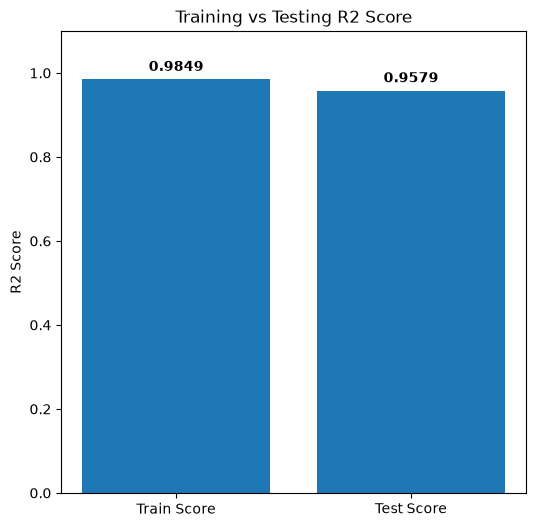

In [6]:
# Car Price Prediction - ML Pipeline

import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. Load dataset

df = pd.read_csv("data/CarPrice_Assignment.csv", index_col="car_ID")


# 2. Define target and features

y = df["price"]
X = df.drop("price", axis=1).copy()


# CarName is text with many unique values.
# We are not using it in this beginner project.
X.drop("CarName", axis=1, inplace=True)

# 3. Define categorical and numerical columns


# We use OneHotEncoder for nominal categorical columns.
categorical_cols = [
    "fueltype",
    "aspiration",
    "doornumber",
    "carbody",
    "drivewheel",
    "enginelocation",
    "enginetype",
    "fuelsystem",
]

# cylindernumber has an ordered meaning in this dataset
# (two, three, four, five, six, eight, twelve).
# We convert it manually to its numeric meaning instead of
# using LabelEncoder.
cylinder_map = {
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12,
}

X["cylindernumber"] = X["cylindernumber"].map(cylinder_map)

# Check for unexpected cylinder values
if X["cylindernumber"].isna().any():
    raise ValueError("Unexpected value found in cylindernumber.")


# Find remaining numeric columns automatically
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


# 4. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# 5. Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", StandardScaler(), numerical_cols),
        ("catagorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

# 6. Model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# 7. Complete ML Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


# 8. Cross-validation for over or under fitting

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R2 Scores:", cv_scores)
print(f"Average CV R2 Score: {cv_scores.mean():.4f}")

# 9. Train final pipeline

pipeline.fit(X_train, y_train)

# 10. Predictions

train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

# 11. Evaluation

train_score = metrics.r2_score(y_train, train_pred)
test_score = metrics.r2_score(y_test, test_pred)

print(f"Train R2 Score: {train_score:.4f}")
print(f"Test R2 Score:  {test_score:.4f}")

# 12. Save complete pipeline

joblib.dump(pipeline, "car_price_pipeline.pkl")

print("Complete pipeline saved as: car_price_pipeline.pkl")

# 13. Plot train vs test score

plt.figure(figsize=(6, 6))

plt.bar(
    ["Train Score", "Test Score"],
    [train_score, test_score]
)

plt.ylabel("R2 Score")
plt.ylim(0, 1.1)
plt.title("Training vs Testing R2 Score")

for i, v in enumerate([train_score, test_score]):
    plt.text(
        i,
        v + 0.02,
        f"{v:.4f}",
        ha="center",
        fontweight="bold"
    )

plt.show()




In [32]:
pred = pipeline.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [38]:
mean_absolute_percentage_error(y_test,pred)

0.09334638339158381